# Convolutional Encoder/Decoder Architectures

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## Dataset: MNIST

For this example, we'll use MNIST. But since we're using `torch` now, we can use the MNIST located in torchvision

In [3]:
import torch
import torchvision
from torchvision.transforms import v2

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])
mnist = torchvision.datasets.MNIST(root='~/scr10/', train=True, transform=transform, download=True)
mnist_test = torchvision.datasets.MNIST(root='~/scr10/', train=False, transform=transform, download=False)
from torch.utils.data import random_split
mnist_train, mnist_val = random_split(mnist, [0.8, 0.2])
print('Training dataset has length', len(mnist_train))
print('Training dataset has length', len(mnist_val))
print('Training dataset has length', len(mnist_test))

Training dataset has length 48000
Training dataset has length 12000
Training dataset has length 10000


In [4]:
x, y = mnist_train[0]
print('Input has shape', x.shape, 'and the output is', y)

Input has shape torch.Size([1, 28, 28]) and the output is 3


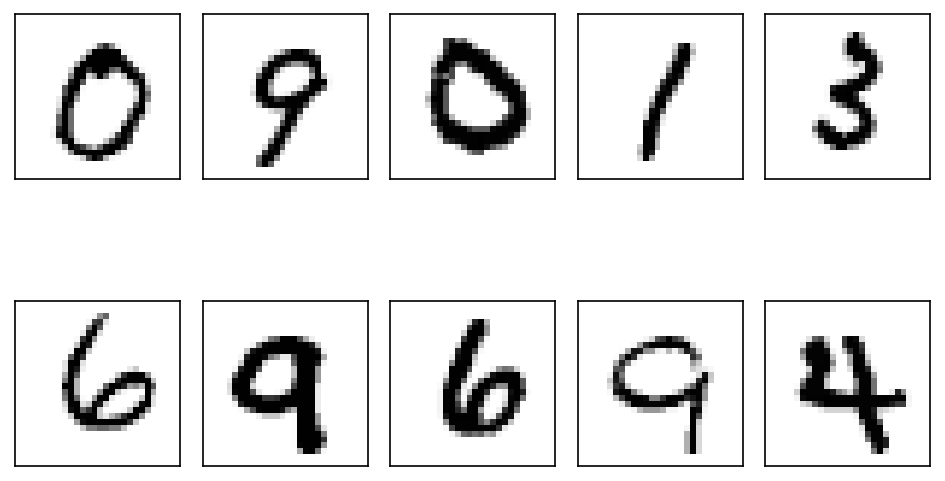

In [5]:
fig, ax = plt.subplots(2, 5, sharex=True, sharey=True)
ax = ax.flatten()
for ii in range(10):
    x, y = mnist_train[np.random.choice(len(mnist_train))]
    ax[ii].imshow(x.squeeze(), cmap='Greys')
    ax[ii].set(xticks=[], yticks=[])
plt.tight_layout()

## CNN definition

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.fc = nn.Linear(64*3*3, 3)

    def forward(self, x):
        # [B, 1, 28, 28]
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        # [B, 16, 14, 14]
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        # [B, 32, 7, 7]
        x = self.conv3(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        # [B, 64, 3, 3]
        x = x.reshape([-1, 64*3*3])
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.ConvTranspose2d(16, 1, kernel_size=3, padding=1)
        self.conv2 = nn.ConvTranspose2d(32, 16, kernel_size=3, padding=1)
        self.conv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, padding=1)

        self.fc = nn.Linear(3, 64*3*3)

    def forward(self, x):
        # [B, 10]
        x = self.fc(x)

        # [B, 64*3*3]
        x = x.reshape([-1, 64, 3, 3])

        x = F.interpolate(x, size=(7, 7))
        x = self.conv3(x)
        x = F.relu(x)

        x = F.interpolate(x, size=(14, 14))
        x = self.conv2(x)
        x = F.relu(x)

        x = F.interpolate(x, size=(28, 28))
        x = self.conv1(x)
        x = F.relu(x)

        return x

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder(z)
        return x, z

In [7]:
model = Autoencoder()
print(x.shape)
xp, zp = model(x[None])

torch.Size([1, 28, 28])


## Autoencoder training

In [8]:
from tqdm.notebook import tqdm, trange
from torch.utils.data import DataLoader

def train(model, loss_fn, optimizer, train_dataset, val_dataset, 
          batch_size=32, num_epochs=100, num_workers=0, device=device):
    # Send model to correct hardware device
    model = model.to(device)

    # Create dataloaders for train/validation
    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

    train_loss = []
    val_loss = []
    
    for epoch in range(num_epochs):
        train_loss_ = 0.
        model.train()
        for x, _, in tqdm(train_loader, leave=False):
            # Send x, y to GPU/TPU/etc.
            x = x.to(device)

            # Make a prediction, compute the loss
            x_pred, z_pred = model(x)
            loss = loss_fn(x_pred, x)

            # Backpropagate gradients, apply weight updates, reset gradients
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Logging
            train_loss_ += loss.item() * x.shape[0]

        train_loss.append(train_loss_ / len(train_dataset))

        val_loss_ = 0.
        model.eval()
        with torch.no_grad():
            for x, y, in tqdm(val_loader, leave=False):
                # Send x, y to GPU/TPU/etc.
                x = x.to(device)
    
                # Make a prediction, compute the loss
                x_pred, z_pred = model(x)
                loss = loss_fn(x_pred, x)
        
                # Logging
                val_loss_ += loss.item() * x.shape[0]

            val_loss.append(val_loss_ / len(val_dataset))

        print(f'Epoch {epoch+1} | '
              f'Train loss { train_loss[-1]:.3f} | '
              f'Val loss { val_loss[-1]:.3f}'
        )

    return model, (train_loss, val_loss)

In [9]:
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model, model_stats = train(
    model, 
    loss, 
    optimizer, 
    mnist_train, 
    mnist_val, 
    num_epochs=10,
    batch_size=64,
    num_workers=4,
)

  0%|          | 0/750 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1 | Train loss 0.045 | Val loss 0.040


  0%|          | 0/750 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

...

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 9 | Train loss 0.035 | Val loss 0.035


  0%|          | 0/750 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 10 | Train loss 0.034 | Val loss 0.035


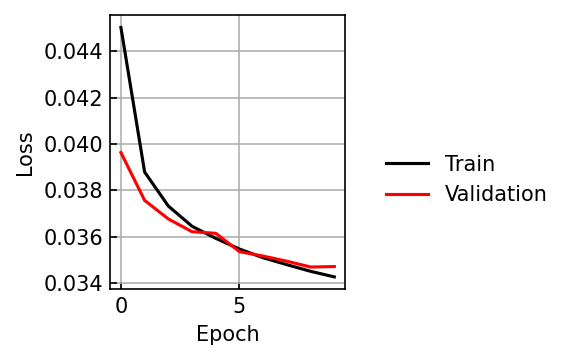

In [10]:
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(2.5, 2.5))

train_loss, val_loss = model_stats
ax.plot(train_loss, color='black', label='Train')
ax.plot(val_loss, color='red', label='Validation')
ax.set(xlabel='Epoch', ylabel='Loss')

fig.legend(*ax.get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

## Inference

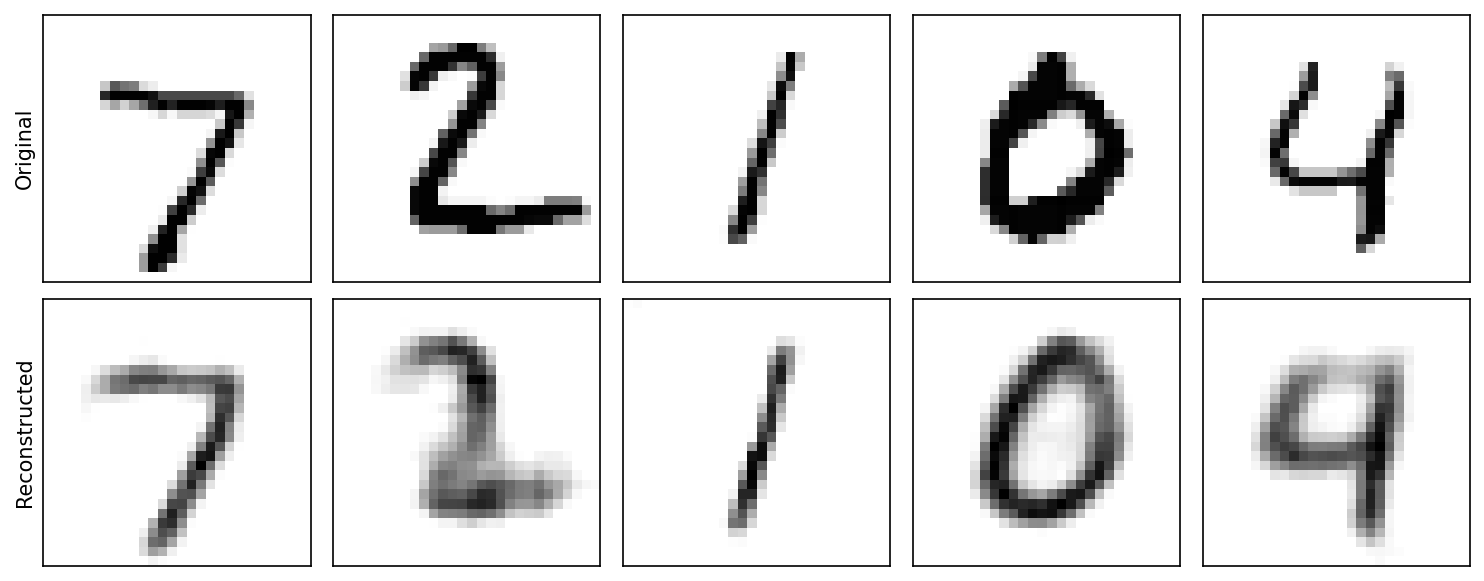

In [11]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4), sharex=True, sharey=True)
for ii in range(5):
    xb, _ = mnist_test[ii]
    ax[0, ii].imshow(xb.squeeze().cpu().numpy(), cmap='Greys')
    with torch.no_grad():
        x_pred, z_pred = model(xb.to(device))
    ax[1, ii].imshow(x_pred.squeeze().cpu().numpy(), cmap='Greys')

ax[0,0].set_ylabel('Original')
ax[1,0].set_ylabel('Reconstructed')

for a in ax.flatten():
    a.set(xticks=[], yticks=[])
plt.tight_layout()

In [12]:
# Inference
model.eval()
test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False)
with torch.no_grad():
    y_test = []
    z_test = []
    for xb, yb in tqdm(test_loader,leave=False):
        xb = xb.to(device)
        x_pred, z_pred = model(xb)

        y_test.append(yb.cpu().numpy())
        z_test.append(z_pred.cpu().numpy())

y_test = np.concatenate(y_test)
z_test = np.concatenate(z_test)

  0%|          | 0/79 [00:00<?, ?it/s]

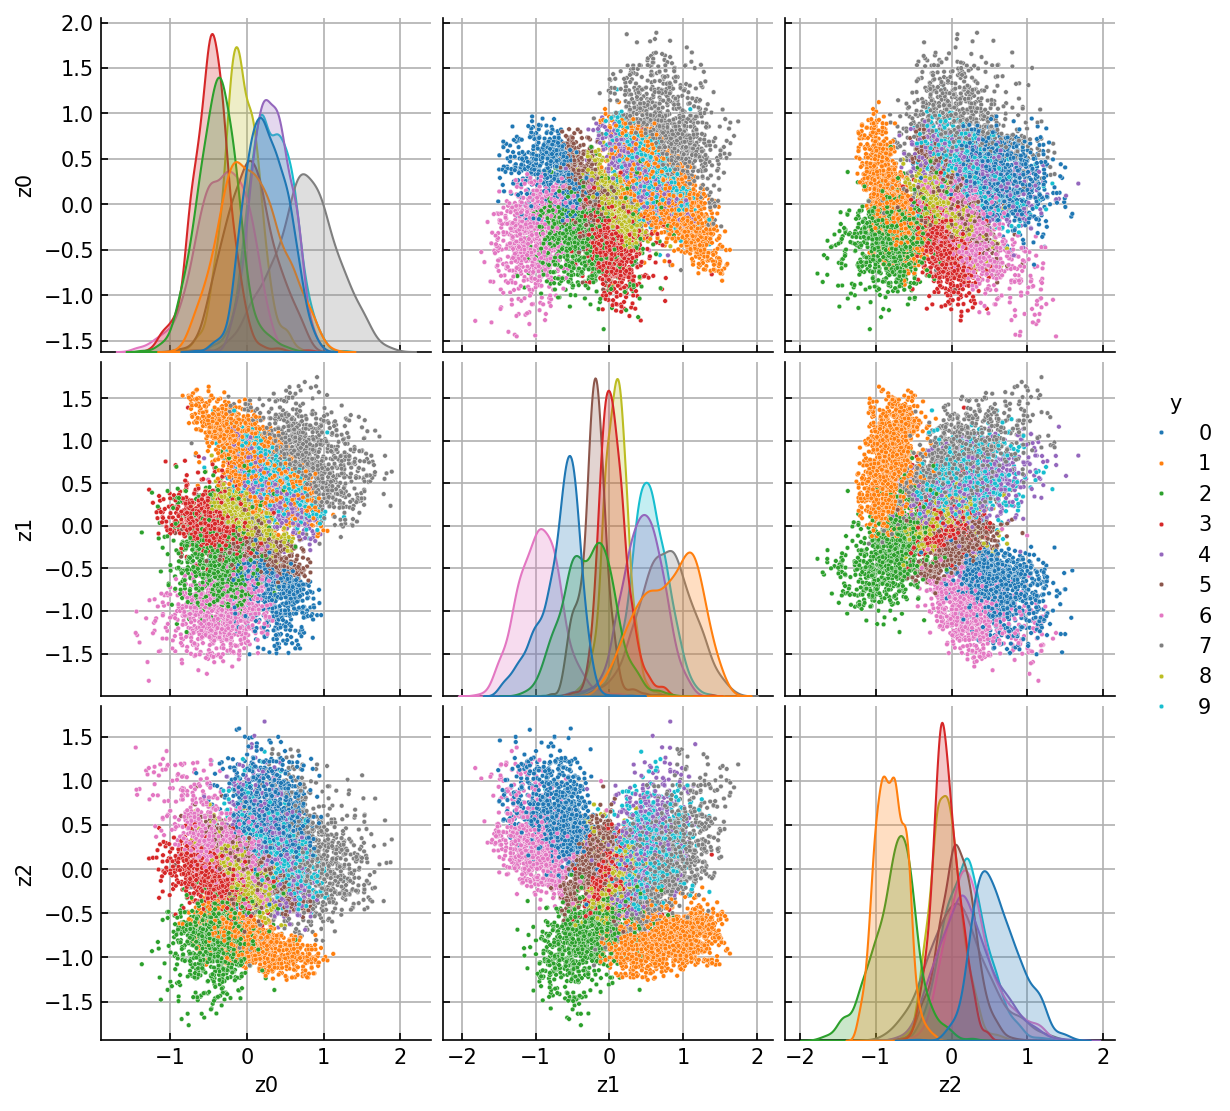

In [13]:
import seaborn as sns

df = pd.DataFrame({
    'z0': z_test[:, 0],
    'z1': z_test[:, 1],
    'z2': z_test[:, 2],
    'y': y_test
})

sns.pairplot(df, hue='y', palette='tab10', plot_kws={'s': 5})